<a href="https://colab.research.google.com/github/AiHuzaifa/iris-multiclass-classifier-scratch/blob/main/Isis_Data_analysis(Logistic_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [1]:
from google.colab import files

uploaded = files.upload()

Saving iris.csv to iris.csv


In [3]:
df = pd.read_csv("iris.csv")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [8]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [10]:
X = df[['petal_length','petal_width','sepal_width','sepal_length']]

In [11]:
y = df['species']

In [18]:
X = X.to_numpy()

In [19]:
y = y.to_numpy()

In [15]:
# from sklearn.preprocessing import LabelEncoder

# # Initialize the LabelEncoder
# le = LabelEncoder()

# # Fit and transform the target species to integers
# y_encoded = le.fit_transform(y)

# # Display the mapping and the encoded target
# print("Class Mapping:")
# for index, class_name in enumerate(le.classes_):
#     print(f"{class_name} -> {index}")

# print("\nFirst 5 encoded values:", y_encoded)
# print("Unique encoded values:", np.unique(y_encoded))

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

# Since y is already a NumPy array, reshape it directly without .values
y_one_hot = ohe.fit_transform(y.reshape(-1, 1))

print("Categories found:", ohe.categories_)
print("\nFirst 5 one-hot encoded arrays:")
for original, encoded in zip(y[:5], y_one_hot[:5]):
    print(f"{original:11} -> {list(encoded.astype(int))}")

Categories found: [array(['setosa', 'versicolor', 'virginica'], dtype=object)]

First 5 one-hot encoded arrays:
setosa      -> [np.int64(1), np.int64(0), np.int64(0)]
setosa      -> [np.int64(1), np.int64(0), np.int64(0)]
setosa      -> [np.int64(1), np.int64(0), np.int64(0)]
setosa      -> [np.int64(1), np.int64(0), np.int64(0)]
setosa      -> [np.int64(1), np.int64(0), np.int64(0)]


In [27]:
class Logistic_Multi_Regression:
  def __init__(self,lr=0.01,n_iters=10000):
    self.lr = lr
    self.n_iters = n_iters
    self.weights = None
    self.base = None

  def softmax(self, z):

    # numerical stability
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    z = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return z
  def fit(self,X,y):
    n_class = len(df["species"].unique())
    self.weights = np.zeros((X.shape[1],n_class))
    self.base = np.zeros(n_class)
    m = X.shape[0]
    for _ in range(self.n_iters):

      y_h = np.dot(X,self.weights) + self.base
      soft_max = self.softmax(y_h)

      # Small value added to prevent log(0), which would give -infinity
      epsilon = 1e-15

      # Cross-Entropy loss: one-hot y ensures only the correct class contributes to loss
      loss = -y * np.log(soft_max + epsilon)

      # Average loss across all training samples
      cost = np.sum(loss) / m

      if _ % 100 == 0:
        print(cost)

      dw = (X.T @ (soft_max - y))/m
      db = np.sum(soft_max - y, axis=0) / m

      self.weights -= self.lr*dw
      self.base -= self.lr*db

  def predict(self,X):
    y_h = np.dot(X,self.weights) + self.base
    soft_max = self.softmax(y_h)
    return np.argmax(soft_max, axis=1)

  def accuracy(self,y_pred,y_test):
    return np.sum(y_pred == y_test) / len(y_test)




In [28]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (120, 4)
Testing set shape: (30, 4)


In [29]:
# Instantiate and train your custom multiclass model on the training set
model = Logistic_Multi_Regression(lr=0.1, n_iters=2000)
model.fit(X_train, y_train)

# Predict on the test set
y_pred_test = model.predict(X_test)

# Convert one-hot encoded y_test back to integer labels for comparison
y_test_labels = np.argmax(y_test, axis=1)

# Calculate and print test accuracy
test_accuracy = model.accuracy(y_pred_test, y_test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

1.0986122886681067
0.44668039381888947
0.2662727680058653
0.22300025778237695
0.1955163454657238
0.1763109138456095
0.16208874416391292
0.15110522369442878
0.14234846749025182
0.13519056507190277
0.12922084844524676
0.12415917004273244
0.11980770129833503
0.116022656250891
0.1126969433157458
0.10974911115112818
0.10711607315757216
0.10474818279056608
0.10260581739618232
0.10065695672149898
Test Accuracy: 100.00%


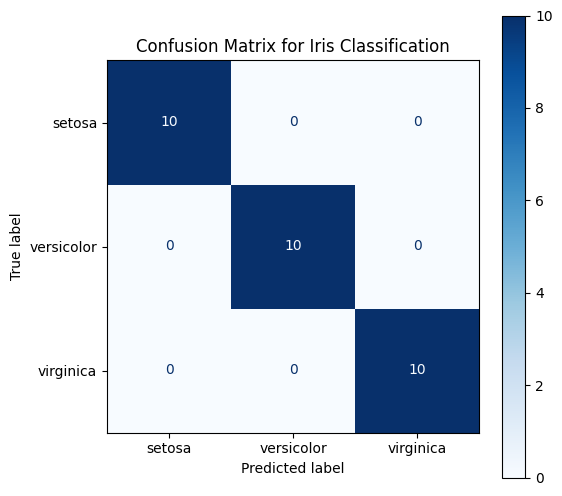

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_test)

# Get class names from our encoder
class_names = ohe.categories_[0]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for Iris Classification")
plt.show()